In [22]:
# Load packages
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(patchwork)
library(tidyverse)
# library(reshape2)
library(stringr)


In [23]:
getwd()

[1] "/home/strawperry/Documents/Masters/growth_curves"

In [24]:
# Load plates
## USA300, HC-B1
pattern_a <- "^160126_.*h\\_a.csv$"   # files starting with DATE and ending in h.csv

## 1253 x 1966
pattern_b <- "^160126_.*h\\_b.csv$"   # files starting with DATE and ending in h.csv

In [25]:
# Check if files were assigned correctly 
files_a <- list.files(pattern = pattern_a, full.names = TRUE)
files_b   <- list.files(pattern = pattern_b,   full.names = TRUE)
files_a
files_b

[1] "./160126_0h_a.csv"  "./160126_24h_a.csv" "./160126_2h_a.csv" 
[4] "./160126_30h_a.csv" "./160126_48h_a.csv" "./160126_4h_a.csv" 
[7] "./160126_6h_a.csv"  "./160126_8h_a.csv"

[1] "./160126_0h_b.csv"  "./160126_24h_b.csv" "./160126_2h_b.csv" 
[4] "./160126_30h_b.csv" "./160126_48h_b.csv" "./160126_4h_b.csv" 
[7] "./160126_6h_b.csv"  "./160126_8h_b.csv"

In [26]:
## ---- Function to process a single plate file ----
process_plate_file <- function(file) {

  ## Extract incubation time (hours) from filename
  ## Example: 160126_24h_a.csv -> 24
  time_hr <- sub(".*_(\\d+)h.*", "\\1", basename(file))
  time_hr <- as.numeric(time_hr)

  ## Identify isolate pair from filename suffix
  isolate_pair <- ifelse(
    grepl("_a\\.csv$", file),
    "USA300_HC-B1",
    "AH1253_AH1956"
  )

  ## Import raw plate data
  raw <- read.csv(
    file,
    header = FALSE,
    skip   = 1,
    na.strings = c("", "NA")
  )

  ## Use first column as row identifiers (A–H)
  rownames(raw) <- raw$V1
  raw <- raw[, -1]

  ## Standardize plate columns (1–12)
  colnames(raw) <- as.character(1:12)

  ## Convert rownames to column
  raw2 <- raw %>%
    tibble::rownames_to_column("Row")

  ## Long format (Row + Column → Well)
  long <- raw2 %>%
    tidyr::pivot_longer(
      cols      = -Row,
      names_to  = "Col",
      values_to = "Value"
    ) %>%
    dplyr::mutate(
      Well = paste0(Row, Col)
    ) %>%
    dplyr::select(Well, Value) %>%
    dplyr::filter(!is.na(Value) & Value != "<NA>")

  ## Ensure numeric values
  long$Value <- as.numeric(gsub(",", ".", long$Value))

  ## Back to wide format (one row per plate/time)
  wide <- long %>%
    tidyr::pivot_wider(
      names_from  = Well,
      values_from = Value
    )

  ## Add metadata columns
  wide <- wide %>%
    dplyr::mutate(
      Time_hr      = time_hr,
      Isolate_Pair = isolate_pair,
      .before = 1
    )

  return(wide)
}

In [27]:
## Process all plates and combine
plates_all <- c(files_a, files_b) %>%
  purrr::map_df(process_plate_file)

glimpse(plates_all)

Rows: 16
Columns: 98
$ Time_hr      <dbl> 0, 24, 2, 30, 48, 4, 6, 8, 0, 24, 2, 30, 48, 4, 6, 8
$ Isolate_Pair <chr> "USA300_HC-B1", "USA300_HC-B1", "USA300_HC-B1", "USA300_H…
$ A1           <dbl> 0.071, 0.258, 0.072, 0.252, 0.250, 0.131, NA, 0.192, 0.07…
$ A2           <dbl> 0.076, 0.262, 0.069, 0.233, 0.183, 0.110, NA, 0.195, 0.07…
$ A3           <dbl> 0.073, 0.278, 0.066, 0.225, 0.099, 0.115, NA, 0.183, 0.07…
$ A4           <dbl> 0.076, 0.339, 0.061, 0.332, 0.302, 0.120, NA, 0.153, 0.07…
$ A5           <dbl> 0.066, 0.336, 0.083, 0.306, 0.274, 0.144, NA, 0.169, 0.06…
$ A6           <dbl> 0.070, 0.349, 0.059, 0.318, 0.302, 0.119, NA, 0.196, 0.07…
$ A7           <dbl> 0.068, 0.233, 0.080, 0.223, 0.215, 0.079, NA, 0.168, 0.06…
$ A8           <dbl> 0.075, 0.227, 0.059, 0.241, 0.182, 0.072, NA, 0.117, 0.07…
$ A9           <dbl> 0.071, 0.232, 0.057, 0.232, 0.233, 0.079, NA, 0.126, 0.07…
$ A10          <dbl> 0.049, 0.050, 0.084, 0.051, 0.049, 0.050, NA, 0.057, 0.04…
$ A11          <dbl> 0.05

In [28]:
head(plates_all)

Time_hr,Isolate_Pair,A1,A2,A3,A4,A5,A6,A7,A8,⋯,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,USA300_HC-B1,0.071,0.076,0.073,0.076,0.066,0.070,0.068,0.075,⋯,0.042,0.041,0.044,0.042,0.050,0.050,0.057,0.051,0.049,0.051
24,USA300_HC-B1,0.258,0.262,0.278,0.339,0.336,0.349,0.233,0.227,⋯,0.052,0.040,0.049,0.048,0.052,0.050,0.048,0.061,0.050,0.051
2,USA300_HC-B1,0.072,0.069,0.066,0.061,0.083,0.059,0.080,0.059,⋯,0.041,0.041,0.043,0.048,0.061,0.050,0.054,0.058,0.051,0.052
30,USA300_HC-B1,0.252,0.233,0.225,0.332,0.306,0.318,0.223,0.241,⋯,0.048,0.060,0.073,0.042,0.056,0.052,0.051,0.073,0.052,0.054
48,USA300_HC-B1,0.250,0.183,0.099,0.302,0.274,0.302,0.215,0.182,⋯,0.055,0.041,0.046,0.046,0.056,0.050,0.049,0.052,0.052,0.048
4,USA300_HC-B1,0.131,0.110,0.115,0.120,0.144,0.119,0.079,0.072,⋯,0.056,0.041,0.074,0.051,0.059,0.073,0.049,0.059,0.053,0.061


In [29]:
tail(plates_all)

Time_hr,Isolate_Pair,A1,A2,A3,A4,A5,A6,A7,A8,⋯,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,AH1253_AH1956,0.080,0.082,0.083,0.074,0.075,0.084,0.075,0.092,⋯,0.041,0.040,0.091,0.042,0.052,0.050,0.050,0.051,0.050,0.045
30,AH1253_AH1956,0.273,0.274,0.255,0.259,0.275,0.346,0.240,0.199,⋯,0.042,0.043,0.042,0.044,0.052,0.052,0.059,0.064,0.048,0.052
48,AH1253_AH1956,0.270,0.233,0.285,0.275,0.268,0.324,0.236,0.204,⋯,0.046,0.044,0.048,0.041,0.053,0.051,0.057,0.049,0.060,0.063
4,AH1253_AH1956,0.168,0.150,0.147,0.125,0.108,0.117,0.097,0.087,⋯,0.051,0.060,0.055,0.090,0.075,0.076,0.080,0.073,0.052,0.162
6,AH1253_AH1956,0.205,0.226,0.208,0.147,0.146,0.156,0.128,0.153,⋯,0.058,0.060,0.074,0.043,0.065,0.052,0.049,0.051,0.049,0.050
8,AH1253_AH1956,0.251,0.266,0.254,0.200,0.203,0.236,0.156,0.179,⋯,0.050,0.049,0.051,0.049,0.053,0.050,0.049,0.087,0.074,0.057


In [30]:
## ---- Helper function: reshape and annotate OD data ----
reshape_od <- function(df) {

  df %>%
    ## Convert plate from wide (A1–H12) to long format
    pivot_longer(
      cols      = -c(Time_hr, Isolate_Pair),
      names_to  = "Well",
      values_to = "OD"
    ) %>%
    
    mutate(
      ## Clean well IDs defensively
      Well = str_trim(Well),

      ## Extract plate coordinates
      Row = str_extract(Well, "^[A-H]"),
      Col = as.numeric(str_extract(Well, "\\d+")),

      ## Carbon source by column grouping
      Carbon = case_when(
        Col %in% c(1, 2, 3) ~ "M9_GLU",
        Col %in% c(4, 5, 6) ~ "M9_SIA",
        Col %in% c(7, 8, 9) ~ "M9",
        TRUE                ~ NA_character_
      ),

      ## Strain identity conditional on isolate pair
      Strain = case_when(

        ## USA300 / HC-B1 plates (_a)
        Isolate_Pair == "USA300_HC-B1" & Row %in% c("A", "B", "C") ~ "USA300",
        Isolate_Pair == "USA300_HC-B1" & Row %in% c("E", "F", "G") ~ "HC-B1",

        ## AH1253 / AH1956 plates (_b)
        Isolate_Pair == "AH1253_AH1956" & Row %in% c("A", "B", "C") ~ "AH1253",
        Isolate_Pair == "AH1253_AH1956" & Row %in% c("E", "F", "G") ~ "AH1956",

        ## Blanks (shared logic)
        Row == "H" ~ "Blank",

        TRUE ~ NA_character_
      ),

      ## Ensure OD is numeric
      OD = as.numeric(OD)
    )
}

## ---- Apply reshaping to the full dataset ----
od_tp_long <- reshape_od(plates_all)

## ---- Final sanity checks ----
table(od_tp_long$Isolate_Pair, od_tp_long$Strain)
table(od_tp_long$Carbon)
unique(od_tp_long$Time_hr)

               
                AH1253 AH1956 Blank HC-B1 USA300
  AH1253_AH1956    288    288    96     0      0
  USA300_HC-B1       0      0    96   288    288


    M9 M9_GLU M9_SIA 
   384    384    384 

[1]  0 24  2 30 48  4  6  8

In [31]:
head(od_tp_long)

Time_hr,Isolate_Pair,Well,OD,Row,Col,Carbon,Strain
<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
0,USA300_HC-B1,A1,0.071,A,1,M9_GLU,USA300
0,USA300_HC-B1,A2,0.076,A,2,M9_GLU,USA300
0,USA300_HC-B1,A3,0.073,A,3,M9_GLU,USA300
0,USA300_HC-B1,A4,0.076,A,4,M9_SIA,USA300
0,USA300_HC-B1,A5,0.066,A,5,M9_SIA,USA300
0,USA300_HC-B1,A6,0.070,A,6,M9_SIA,USA300


In [32]:
# Remove unwanted wells
od_tp_long2 <- od_tp_long %>%
  filter(
    !Row %in% c("D","H"), 
    !Col %in% c(10, 11, 12))
head(od_tp_long2)

Time_hr,Isolate_Pair,Well,OD,Row,Col,Carbon,Strain
<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
0,USA300_HC-B1,A1,0.071,A,1,M9_GLU,USA300
0,USA300_HC-B1,A2,0.076,A,2,M9_GLU,USA300
0,USA300_HC-B1,A3,0.073,A,3,M9_GLU,USA300
0,USA300_HC-B1,A4,0.076,A,4,M9_SIA,USA300
0,USA300_HC-B1,A5,0.066,A,5,M9_SIA,USA300
0,USA300_HC-B1,A6,0.070,A,6,M9_SIA,USA300


In [33]:
write_tsv(od_tp_long2, "saureus_m9_160126.tsv")

In [42]:
plot_growth_pair <- function(df, pair_label) {

  ggplot(
    df %>%
      filter(
        Isolate_Pair == pair_label,
        !is.na(Carbon),
        Strain != "Blank"
      ),
    aes(x = Time_hr, y = OD)
  ) +
    geom_point(
      aes(group = Well),
      color = "lightgray",
      size  = 1,
      alpha = 0.6
    ) +
    geom_smooth(
      aes(color = Carbon, group = Carbon),
      method = "loess",
      span   = 0.8,
      se     = TRUE,
      linewidth = 1
    ) +
    facet_wrap(
      ~ Strain,
      ncol = 1,
      scales = "free_y"
    ) +
    scale_color_brewer(palette = "Set1") +
    scale_y_continuous(limits = c(0.05, 0.4)) +
    labs(
      # title = "Modified M9 Medium",
      x = "Time (h)",
      y = "OD600",
      color = "Carbon source"
    ) +
    theme_bw() +
    theme(
  strip.text   = element_text(face = "bold", size = 11),
  axis.title   = element_text(face = "bold"),
  axis.text    = element_text(face = "bold"),
  legend.title = element_text(face = "bold"),
  legend.text  = element_text(face = "bold"),
  plot.title   = element_text(face = "bold", hjust = 0.5)
    )
}


p_USA_HC  <- plot_growth_pair(od_tp_long2, "USA300_HC-B1")
p_1253_56 <- plot_growth_pair(od_tp_long2, "AH1253_AH1956")


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 9 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_point()`).”


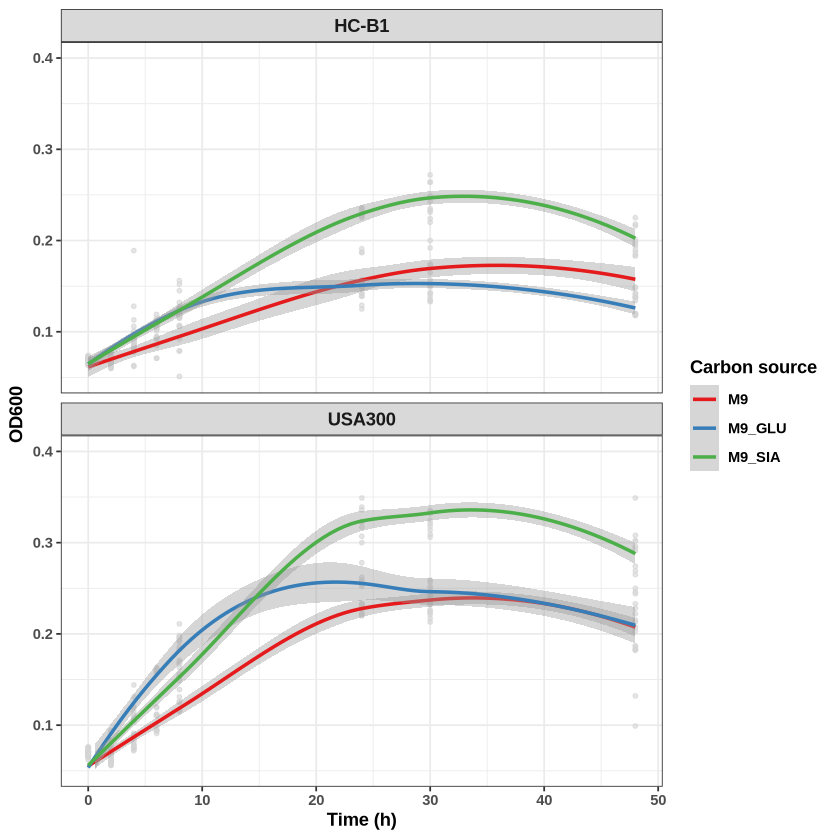

In [43]:
p_USA_HC

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


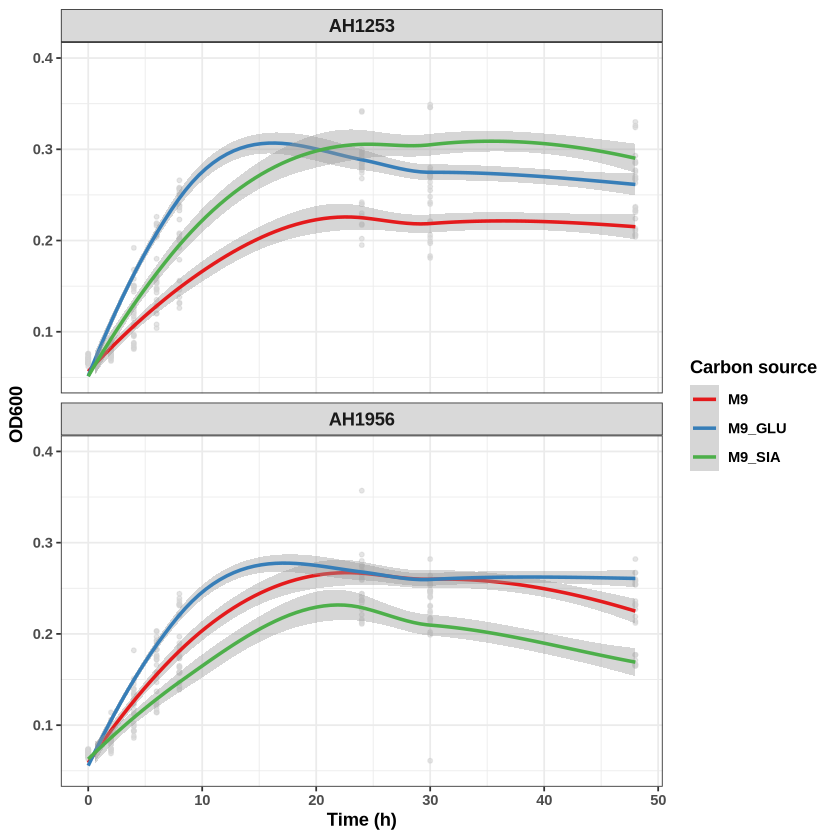

In [44]:
p_1253_56

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 9 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_point()`).”


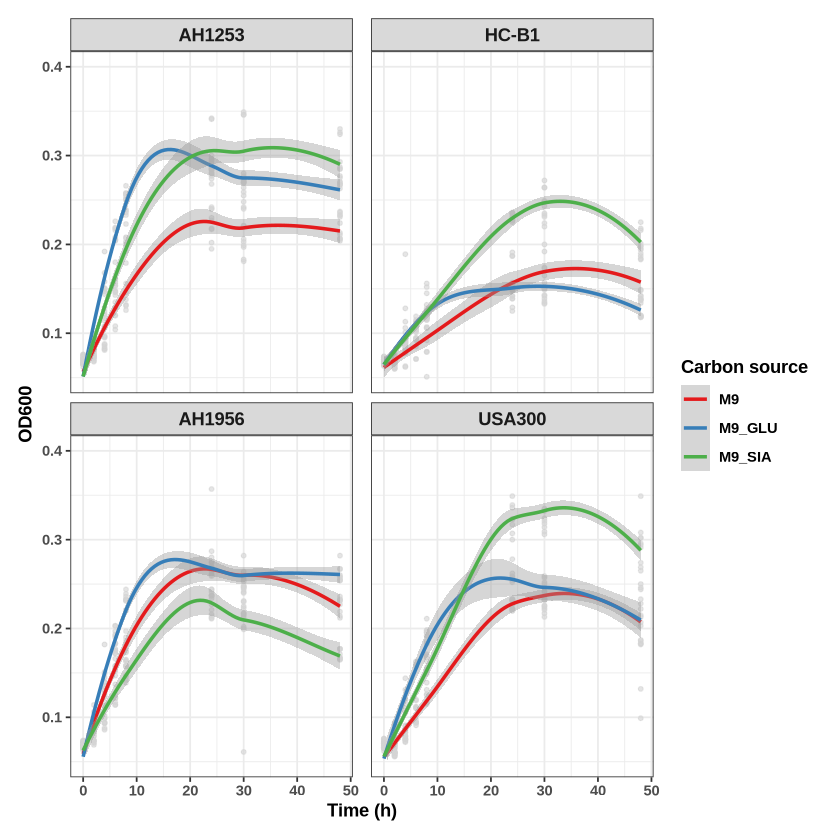

In [45]:
library(patchwork)

final_plot <- (p_1253_56 | p_USA_HC) +
  plot_layout(
    guides = "collect",   # collect legends
    axes   = "collect"    # collect x and y axes
  ) &
  theme(
    legend.position = "right"   # or "bottom"
  )

final_plot


In [46]:
ggsave(
  filename = "growth_curves_M9_aureus_160126.png",
  plot     = final_plot
)

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 9 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_point()`).”


In [47]:
############################################################
## µmax estimation from growth curves
## Method: maximum slope of ln(OD) vs Time
############################################################

library(dplyr)
library(tidyr)
library(purrr)

## ---- Function to estimate µmax for a single well ----
estimate_mu <- function(df) {

  df <- df %>%
    arrange(Time_hr) %>%
    filter(OD > 0)

  ## Require enough points to estimate slope
  if (nrow(df) < 4) return(NA_real_)

  ## Log-transform OD
  df <- df %>%
    mutate(logOD = log(OD))

  ## Compute discrete slopes between consecutive time points
  slopes <- diff(df$logOD) / diff(df$Time_hr)

  ## Return maximum slope (µmax)
  max(slopes, na.rm = TRUE)
}

## ---- Apply µmax estimation per well ----
mu_well <- od_tp_long %>%
  filter(
    Strain != "Blank",
    !is.na(Carbon),
    OD > 0
  ) %>%
  group_by(
    Medium,
    Strain,
    Carbon,
    Well
  ) %>%
  summarise(
    mu_max = estimate_mu(cur_data()),
    .groups = "drop"
  )


ERROR: [1m[33mError[39m in `group_by()`:[22m
[1m[22m[33m![39m Must group by variables found in `.data`.
[31m✖[39m Column `Medium` is not found.


In [17]:
mu_well

Medium,Strain,Carbon,Well,mu_max
<chr>,<chr>,<chr>,<chr>,<dbl>
Classic M9,HC-B1,M9,E7,0.12649826
Classic M9,HC-B1,M9,E8,0.13456433
Classic M9,HC-B1,M9,E9,0.05639775
Classic M9,HC-B1,M9,F7,0.12891455
Classic M9,HC-B1,M9,F8,0.07396007
Classic M9,HC-B1,M9,F9,0.06988097
Classic M9,HC-B1,M9,G7,0.11741980
Classic M9,HC-B1,M9,G8,0.08630637
Classic M9,HC-B1,M9,G9,0.05561282


In [18]:
############################################################
## Aggregate technical replicates
############################################################

mu_summary <- mu_well %>%
  group_by(
    Medium,
    Strain,
    Carbon
  ) %>%
  summarise(
    mu_mean = mean(mu_max, na.rm = TRUE),
    mu_sd   = sd(mu_max, na.rm = TRUE),
    n       = sum(!is.na(mu_max)),
    .groups = "drop"
  )
mu_summary

Medium,Strain,Carbon,mu_mean,mu_sd,n
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
Classic M9,HC-B1,M9,0.09439499,0.03239933,9
Classic M9,HC-B1,M9_GLU,0.21220418,0.02079454,9
Classic M9,HC-B1,M9_SIA,0.15961690,0.04364133,9
Classic M9,USA300,M9,0.18185922,0.02660061,9
Classic M9,USA300,M9_GLU,0.26116870,0.03112776,9
Classic M9,USA300,M9_SIA,0.25000398,0.03044264,9
Modified M9,HC-B1,M9,0.08131503,0.02513734,9
Modified M9,HC-B1,M9_GLU,0.14753017,0.01965229,9
Modified M9,HC-B1,M9_SIA,0.18036759,0.01904590,9


In [20]:
############################################################
## Statistical comparison between media
############################################################

mu_stats <- mu_well %>%
  group_by(
    Strain,
    Carbon
  ) %>%
  summarise(
    p_value = wilcox.test(
      mu_max ~ Medium,
      exact = FALSE
    )$p.value,
    .groups = "drop"
  ) %>%
  mutate(
    p_adj = p.adjust(p_value, method = "BH")
  )
mu_stats

Strain,Carbon,p_value,p_adj
<chr>,<chr>,<dbl>,<dbl>
HC-B1,M9,0.4267767365,0.426776737
HC-B1,M9_GLU,0.0004094601,0.002456761
HC-B1,M9_SIA,0.0168330921,0.020199711
USA300,M9,0.0061138114,0.009250131
USA300,M9_GLU,0.0061667542,0.009250131
USA300,M9_SIA,0.0035514648,0.009250131


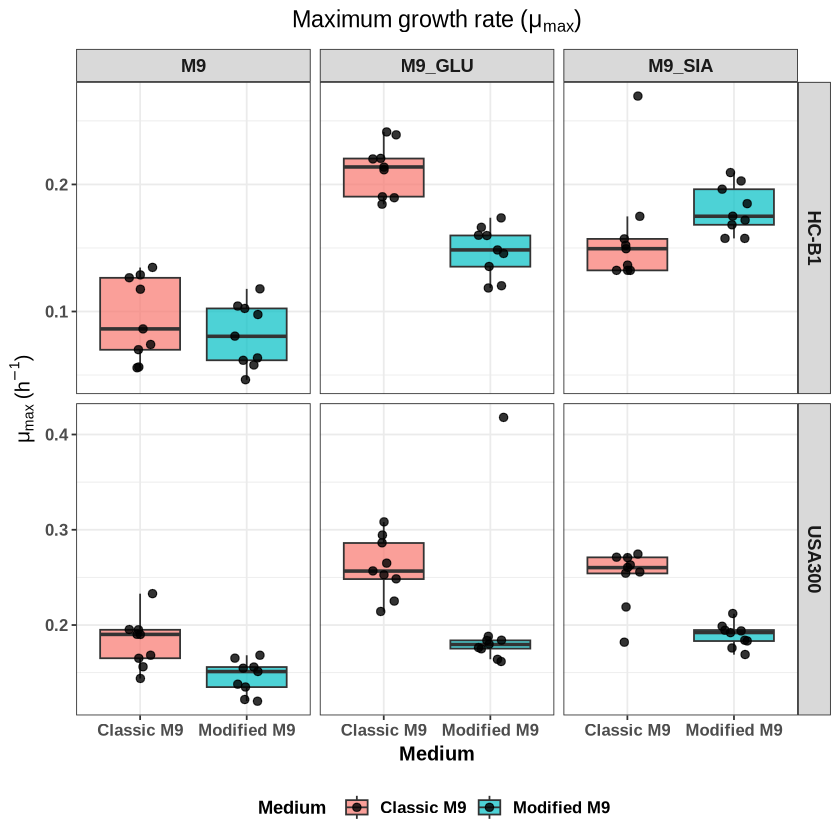

In [22]:
############################################################
## Plot µmax comparison
############################################################
plot_mu <- ggplot(
  mu_well,
  aes(x = Medium, y = mu_max, fill = Medium)
) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA) +
  geom_jitter(width = 0.15, size = 2, alpha = 0.8) +
  facet_grid(Strain ~ Carbon, scales = "free_y") +
  labs(
    x = "Medium",
    y = expression(mu[max]~"(h"^{-1}*")"),
    title = expression("Maximum growth rate ("*mu[max]*")")
  ) +
  theme_bw() +
  theme(
    ## Global text
    text = element_text(face = "bold"),

    ## Axis-specific
    axis.title = element_text(size = 12),
    axis.text  = element_text(size = 10),

    ## Facet strips
    strip.text = element_text(size = 11),

    ## Legend
    legend.position = "bottom",
    legend.title    = element_text(size = 11),
    legend.text     = element_text(size = 10),

    ## Plot title
    plot.title = element_text(size = 14, hjust = 0.5)
  )

plot_mu

In [23]:
ggsave(
  filename = "growth_rates_M9_classic_vs_modified.png",
  plot     = plot_mu,
  width    = 10,
  height   = 6,
  units    = "in"
)

In [25]:
############################################################
## Prepare statistics table for annotation
############################################################

library(dplyr)

mu_stats_plot <- mu_well %>%
  group_by(Strain, Carbon) %>%
  summarise(
    p_value = wilcox.test(mu_max ~ Medium, exact = FALSE)$p.value,
    .groups = "drop"
  ) %>%
  mutate(
    p_adj = p.adjust(p_value, method = "BH"),
    label = case_when(
      p_adj < 0.001 ~ "***",
      p_adj < 0.01  ~ "**",
      p_adj < 0.05  ~ "*",
      TRUE          ~ "ns"
    ),

    ## Define comparison groups explicitly
    group1 = "Classic M9",
    group2 = "Modified M9"
  )
mu_stats_plot

Strain,Carbon,p_value,p_adj,label,group1,group2
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
HC-B1,M9,0.4267767365,0.426776737,ns,Classic M9,Modified M9
HC-B1,M9_GLU,0.0004094601,0.002456761,**,Classic M9,Modified M9
HC-B1,M9_SIA,0.0168330921,0.020199711,*,Classic M9,Modified M9
USA300,M9,0.0061138114,0.009250131,**,Classic M9,Modified M9
USA300,M9_GLU,0.0061667542,0.009250131,**,Classic M9,Modified M9
USA300,M9_SIA,0.0035514648,0.009250131,**,Classic M9,Modified M9


In [29]:
############################################################
## Compute y positions per Strain × Carbon
############################################################

y_pos <- mu_well %>%
  group_by(Strain, Carbon) %>%
  summarise(
    y.position = max(mu_max, na.rm = TRUE) * 1.15,
    .groups = "drop"
  )

mu_stats_plot2 <- mu_stats_plot %>%
  left_join(y_pos, by = c("Strain", "Carbon"))


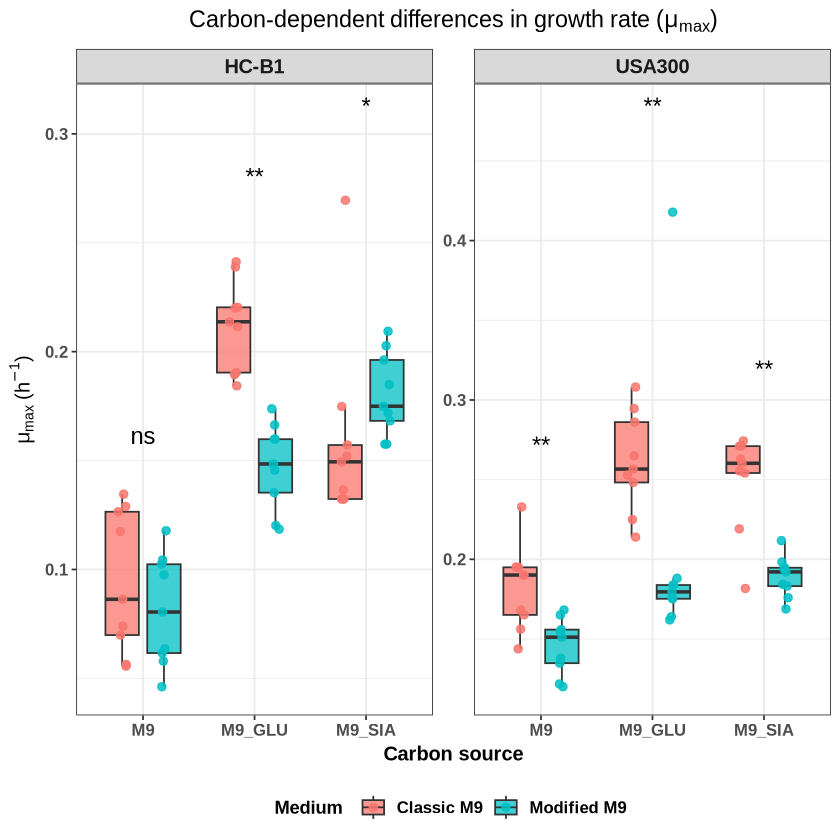

In [30]:
############################################################
## µmax comparison per carbon source
############################################################

library(ggplot2)
library(ggpubr)
library(dplyr)

plot_mu_carbon <- ggplot(
  mu_well,
  aes(x = Carbon, y = mu_max, fill = Medium)
) +
  ## Boxplots per medium
  geom_boxplot(
    position = position_dodge(width = 0.75),
    width = 0.6,
    alpha = 0.75,
    outlier.shape = NA
  ) +
  
  ## Individual well-level points
  geom_jitter(
    aes(color = Medium),
    position = position_jitterdodge(
      jitter.width = 0.15,
      dodge.width  = 0.75
    ),
    size = 2,
    alpha = 0.85
  ) +
  
  ## Statistical significance (Classic vs Modified per carbon)
  stat_pvalue_manual(
    mu_stats_plot2,
    label = "label",
    xmin = "Carbon",
    xmax = "Carbon",
    y.position = "y.position",
    tip.length = 0,
    size = 5
  ) +
  
  facet_wrap(~Strain, scales = "free_y") +
  labs(
    x = "Carbon source",
    y = expression(mu[max]~"(h"^{-1}*")"),
    fill  = "Medium",
    color = "Medium",
    title = expression("Carbon-dependent differences in growth rate ("*mu[max]*")")
  ) +
  theme_bw() +
  theme(
    text = element_text(face = "bold"),
    axis.title = element_text(size = 12),
    axis.text  = element_text(size = 10),
    strip.text = element_text(size = 12),
    legend.position = "bottom",
    legend.title = element_text(size = 11),
    legend.text  = element_text(size = 10),
    plot.title = element_text(size = 14, hjust = 0.5)
  )

plot_mu_carbon


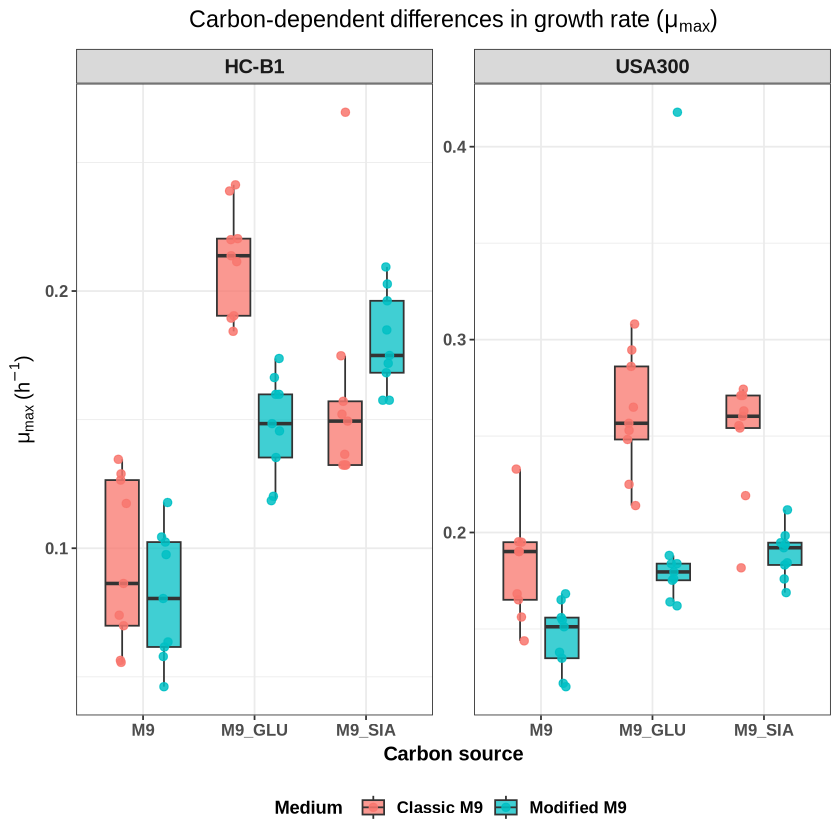

In [31]:
############################################################
## µmax comparison per carbon source (no stats annotation)
############################################################

library(ggplot2)
library(dplyr)

plot_mu_carbon_clean <- ggplot(
  mu_well,
  aes(x = Carbon, y = mu_max, fill = Medium)
) +
  ## Boxplots per medium
  geom_boxplot(
    position = position_dodge(width = 0.75),
    width = 0.6,
    alpha = 0.75,
    outlier.shape = NA
  ) +
  
  ## Individual well-level points
  geom_jitter(
    aes(color = Medium),
    position = position_jitterdodge(
      jitter.width = 0.15,
      dodge.width  = 0.75
    ),
    size = 2,
    alpha = 0.85
  ) +
  
  ## Facet by strain
  facet_wrap(~Strain, scales = "free_y") +
  
  ## Labels
  labs(
    x = "Carbon source",
    y = expression(mu[max]~"(h"^{-1}*")"),
    fill  = "Medium",
    color = "Medium",
    title = expression("Carbon-dependent differences in growth rate ("*mu[max]*")")
  ) +
  
  ## Theme
  theme_bw() +
  theme(
    text = element_text(face = "bold"),
    axis.title = element_text(size = 12),
    axis.text  = element_text(size = 10),
    strip.text = element_text(size = 12),
    legend.position = "bottom",
    legend.title = element_text(size = 11),
    legend.text  = element_text(size = 10),
    plot.title = element_text(size = 14, hjust = 0.5)
  )

plot_mu_carbon_clean


In [33]:
ggsave(
  filename = "growth_rates_M9_PERCARB-modifxclassic2.png",
  plot     = plot_mu_carbon_clean,
  width    = 10,
  height   = 6,
  units    = "in"
)